# YOLOv8m Face Mask Detection - Precision & Recall Analysis

This notebook visualizes the precision and recall statistics from the trained YOLOv8m model.

In [12]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Configuration
PROJECT_DIR = Path("..").resolve()
RUNS_DIR = PROJECT_DIR / "runs" / "face_mask_detection_yolov8m_v2"
MODELS_DIR = PROJECT_DIR / "models"

print(f"Project Directory: {PROJECT_DIR}")
print(f"Runs Directory: {RUNS_DIR}")
print(f"Runs Directory Exists: {RUNS_DIR.exists()}")


Project Directory: /home/khoanguyen/workspace/UIT/face_mask_detection
Runs Directory: /home/khoanguyen/workspace/UIT/face_mask_detection/runs/face_mask_detection_yolov8m_v2
Runs Directory Exists: True


In [13]:
# Load training results
results_csv = RUNS_DIR / "results.csv"

if results_csv.exists():
    print("✓ Found training results.csv")
    df_results = pd.read_csv(results_csv)
    print(f"\nDataset shape: {df_results.shape}")
    print(f"\nColumns: {list(df_results.columns)}")
    print(f"\nFirst few rows:")
    print(df_results.head())
else:
    print("❌ results.csv not found. Make sure training is completed.")
    df_results = None

✓ Found training results.csv

Dataset shape: (100, 15)

Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

First few rows:
   epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1  40.8775          2.0737          2.3630          1.5638   
1      2  79.3798          1.4393          1.1959          1.1390   
2      3 117.4460          1.3521          1.1085          1.0836   
3      4 155.5160          1.4294          1.0161          1.0956   
4      5 193.4850          1.3022          0.9438          1.0516   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0                0.7064             0.3540            0.3735   
1                0.8747             0.4520            0.5150   
2                0.8559             0.4843            0.5462   
3        

## Precision & Recall Statistics

In [22]:
if df_results is not None:
    # Extract precision and recall columns
    # YOLOv8 naming: metrics/precision(B), metrics/recall(B)
    precision_cols = [col for col in df_results.columns if 'precision' in col.lower()]
    recall_cols = [col for col in df_results.columns if 'recall' in col.lower()]
    
    print("📊 PRECISION & RECALL STATISTICS")
    print("=" * 60)
    
    # Check which precision/recall columns exist
    print(f"\nAvailable Precision columns: {precision_cols}")
    print(f"Available Recall columns: {recall_cols}")
    
    # Get the main precision and recall columns
    if precision_cols:
        main_precision_col = precision_cols[0]
        precision_values = df_results[main_precision_col].dropna()
        if len(precision_values) > 0:
            print(f"\n🎯 PRECISION Metrics ({main_precision_col}):")
            print(f"  Mean:   {precision_values.mean():.4f}")
            print(f"  Max:    {precision_values.max():.4f}")
            print(f"  Min:    {precision_values.min():.4f}")
            print(f"  Std:    {precision_values.std():.4f}")
            print(f"  Final:  {precision_values.iloc[-1]:.4f}")
    
    if recall_cols:
        main_recall_col = recall_cols[0]
        recall_values = df_results[main_recall_col].dropna()
        if len(recall_values) > 0:
            print(f"\n🔍 RECALL Metrics ({main_recall_col}):")
            print(f"  Mean:   {recall_values.mean():.4f}")
            print(f"  Max:    {recall_values.max():.4f}")
            print(f"  Min:    {recall_values.min():.4f}")
            print(f"  Std:    {recall_values.std():.4f}")
            print(f"  Final:  {recall_values.iloc[-1]:.4f}")
    
    print("\n" + "=" * 60)

📊 PRECISION & RECALL STATISTICS

Available Precision columns: ['metrics/precision(B)']
Available Recall columns: ['metrics/recall(B)']

🎯 PRECISION Metrics (metrics/precision(B)):
  Mean:   0.7998
  Max:    0.9191
  Min:    0.5188
  Std:    0.0715
  Final:  0.8706

🔍 RECALL Metrics (metrics/recall(B)):
  Mean:   0.7314
  Max:    0.8559
  Min:    0.3540
  Std:    0.0883
  Final:  0.7880



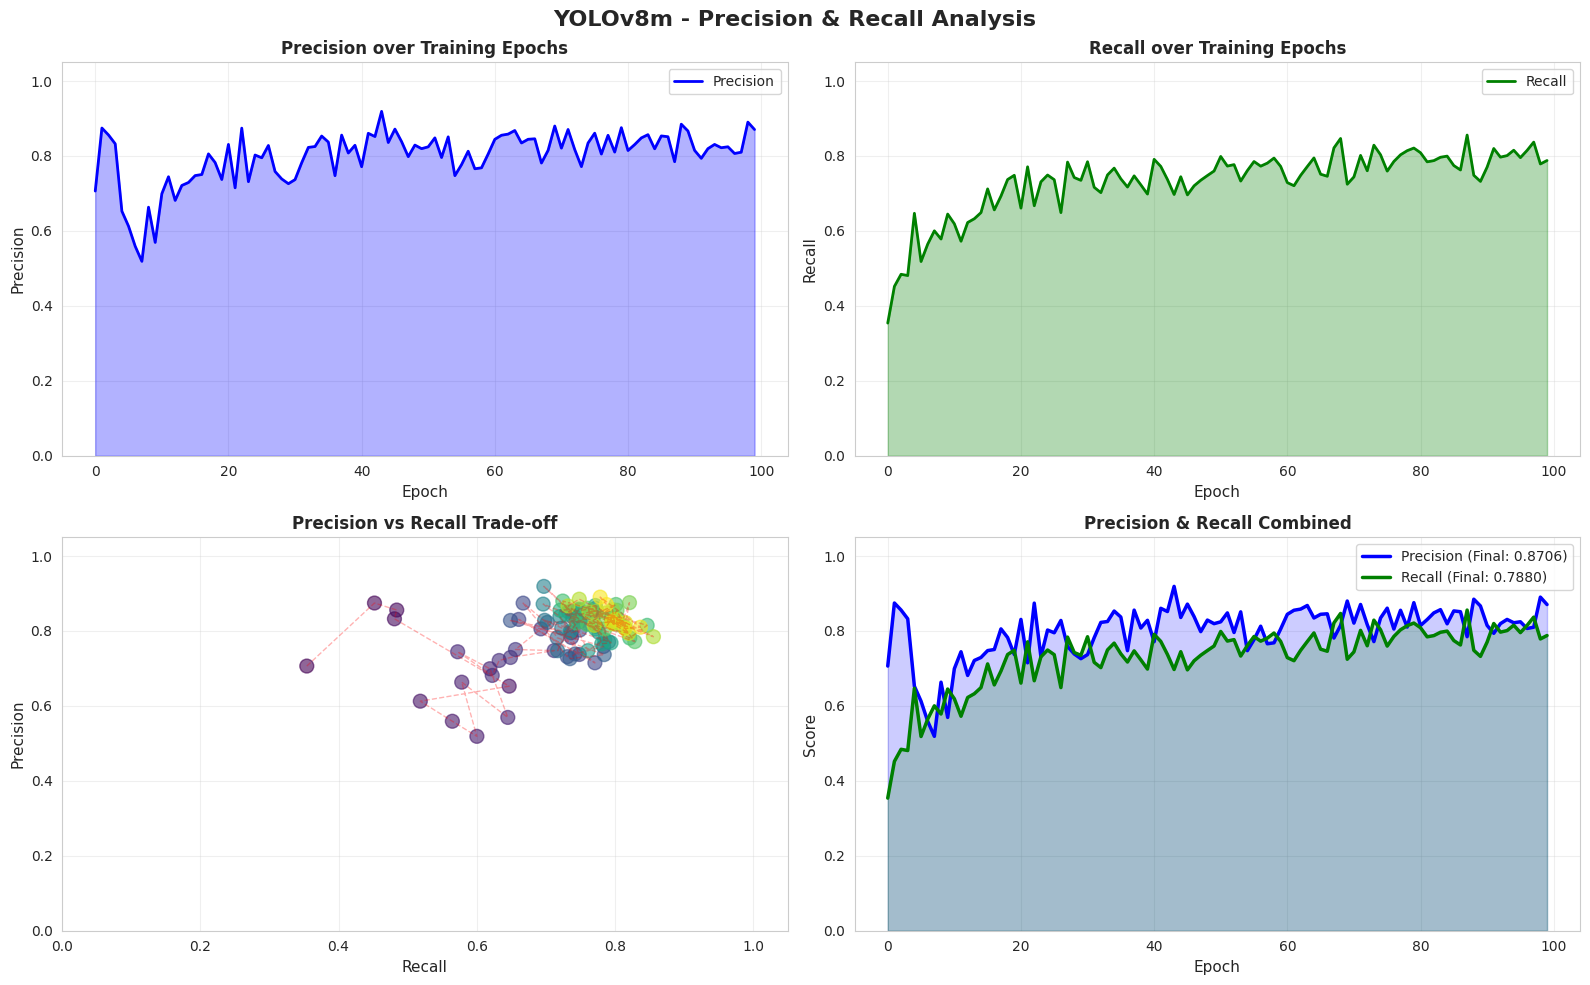


✓ Visualization completed


In [15]:
if df_results is not None and precision_cols and recall_cols:
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('YOLOv8m - Precision & Recall Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Precision over epochs
    ax1 = axes[0, 0]
    precision_values = df_results[main_precision_col].dropna()
    ax1.plot(precision_values.index, precision_values.values, 'b-', linewidth=2, label='Precision')
    ax1.fill_between(precision_values.index, precision_values.values, alpha=0.3, color='blue')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Precision', fontsize=11)
    ax1.set_title('Precision over Training Epochs', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim([0, 1.05])
    
    # Plot 2: Recall over epochs
    ax2 = axes[0, 1]
    recall_values = df_results[main_recall_col].dropna()
    ax2.plot(recall_values.index, recall_values.values, 'g-', linewidth=2, label='Recall')
    ax2.fill_between(recall_values.index, recall_values.values, alpha=0.3, color='green')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Recall', fontsize=11)
    ax2.set_title('Recall over Training Epochs', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_ylim([0, 1.05])
    
    # Plot 3: Precision vs Recall (Scatter)
    ax3 = axes[1, 0]
    ax3.scatter(recall_values.values, precision_values.values, c=range(len(precision_values)), 
               cmap='viridis', s=100, alpha=0.6)
    ax3.plot(recall_values.values, precision_values.values, 'r--', alpha=0.3, linewidth=1)
    ax3.set_xlabel('Recall', fontsize=11)
    ax3.set_ylabel('Precision', fontsize=11)
    ax3.set_title('Precision vs Recall Trade-off', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim([0, 1.05])
    ax3.set_ylim([0, 1.05])
    
    # Plot 4: Combined Precision & Recall
    ax4 = axes[1, 1]
    ax4.plot(precision_values.index, precision_values.values, 'b-', linewidth=2.5, 
            label=f'Precision (Final: {precision_values.iloc[-1]:.4f})')
    ax4.plot(recall_values.index, recall_values.values, 'g-', linewidth=2.5, 
            label=f'Recall (Final: {recall_values.iloc[-1]:.4f})')
    ax4.fill_between(precision_values.index, precision_values.values, alpha=0.2, color='blue')
    ax4.fill_between(recall_values.index, recall_values.values, alpha=0.2, color='green')
    ax4.set_xlabel('Epoch', fontsize=11)
    ax4.set_ylabel('Score', fontsize=11)
    ax4.set_title('Precision & Recall Combined', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=10)
    ax4.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization completed")
else:
    print("❌ Unable to create visualizations. Training results not available.")

## Detailed Metrics Summary Table

In [16]:
if df_results is not None and precision_cols and recall_cols:
    # Create summary statistics table
    summary_data = {
        'Metric': ['Precision', 'Recall'],
        'Mean': [
            df_results[main_precision_col].mean(),
            df_results[main_recall_col].mean()
        ],
        'Max': [
            df_results[main_precision_col].max(),
            df_results[main_recall_col].max()
        ],
        'Min': [
            df_results[main_precision_col].min(),
            df_results[main_recall_col].min()
        ],
        'Std Dev': [
            df_results[main_precision_col].std(),
            df_results[main_recall_col].std()
        ],
        'First Epoch': [
            df_results[main_precision_col].iloc[0],
            df_results[main_recall_col].iloc[0]
        ],
        'Last Epoch': [
            df_results[main_precision_col].iloc[-1],
            df_results[main_recall_col].iloc[-1]
        ]
    }
    
    df_summary = pd.DataFrame(summary_data)
    
    # Format for display
    pd.options.display.float_format = '{:.4f}'.format
    
    print("\n" + "=" * 100)
    print("DETAILED PRECISION & RECALL METRICS SUMMARY")
    print("=" * 100)
    print(df_summary.to_string(index=False))
    print("=" * 100)
    
    # Calculate improvements
    precision_improvement = df_results[main_precision_col].iloc[-1] - df_results[main_precision_col].iloc[0]
    recall_improvement = df_results[main_recall_col].iloc[-1] - df_results[main_recall_col].iloc[0]
    
    print(f"\n📈 IMPROVEMENTS (First to Last Epoch):")
    print(f"  Precision Change: {precision_improvement:+.4f} ({(precision_improvement/df_results[main_precision_col].iloc[0]*100):+.2f}%)")
    print(f"  Recall Change:    {recall_improvement:+.4f} ({(recall_improvement/df_results[main_recall_col].iloc[0]*100):+.2f}%)")


DETAILED PRECISION & RECALL METRICS SUMMARY
   Metric   Mean    Max    Min  Std Dev  First Epoch  Last Epoch
Precision 0.7998 0.9191 0.5188   0.0715       0.7064      0.8706
   Recall 0.7314 0.8559 0.3540   0.0883       0.3540      0.7880

📈 IMPROVEMENTS (First to Last Epoch):
  Precision Change: +0.1642 (+23.25%)
  Recall Change:    +0.4340 (+122.58%)


## Additional Training Metrics (Loss, mAP, etc.)


📊 AVAILABLE METRICS IN TRAINING RESULTS:
Loss metrics: ['train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']
mAP metrics: ['metrics/mAP50(B)', 'metrics/mAP50-95(B)']
All columns: 15 metrics tracked


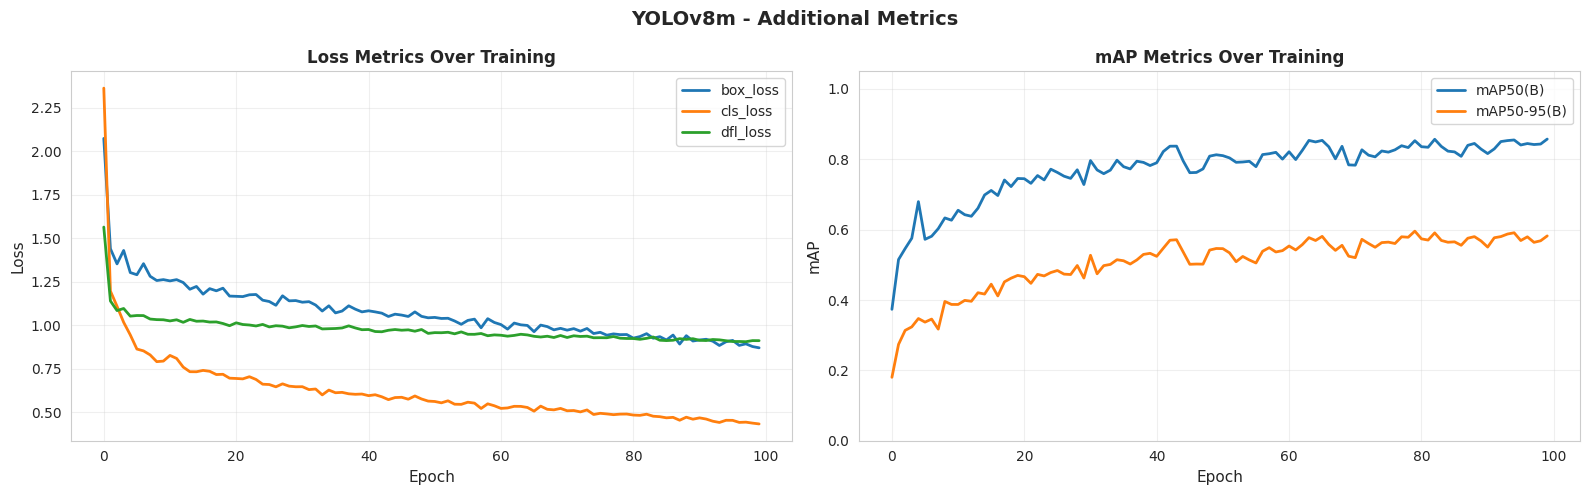

In [17]:
if df_results is not None:
    # Find all available metrics
    all_columns = df_results.columns.tolist()
    
    # Categorize metrics
    loss_cols = [col for col in all_columns if 'loss' in col.lower()]
    map_cols = [col for col in all_columns if 'map' in col.lower()]
    
    print("\n📊 AVAILABLE METRICS IN TRAINING RESULTS:")
    print("=" * 60)
    print(f"Loss metrics: {loss_cols}")
    print(f"mAP metrics: {map_cols}")
    print(f"All columns: {len(all_columns)} metrics tracked")
    
    # Create visualization for additional metrics
    if loss_cols or map_cols:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle('YOLOv8m - Additional Metrics', fontsize=14, fontweight='bold')
        
        # Plot losses
        if loss_cols:
            ax1 = axes[0]
            for col in loss_cols[:3]:  # Plot first 3 loss metrics
                values = df_results[col].dropna()
                if len(values) > 0:
                    ax1.plot(values.index, values.values, linewidth=2, label=col.replace('train/', '').replace('val/', ''))
            ax1.set_xlabel('Epoch', fontsize=11)
            ax1.set_ylabel('Loss', fontsize=11)
            ax1.set_title('Loss Metrics Over Training', fontsize=12, fontweight='bold')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
        
        # Plot mAP
        if map_cols:
            ax2 = axes[1]
            for col in map_cols[:2]:  # Plot first 2 mAP metrics
                values = df_results[col].dropna()
                if len(values) > 0:
                    ax2.plot(values.index, values.values, linewidth=2, label=col.replace('metrics/', ''))
            ax2.set_xlabel('Epoch', fontsize=11)
            ax2.set_ylabel('mAP', fontsize=11)
            ax2.set_title('mAP Metrics Over Training', fontsize=12, fontweight='bold')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            ax2.set_ylim([0, 1.05])
        
        plt.tight_layout()
        plt.show()

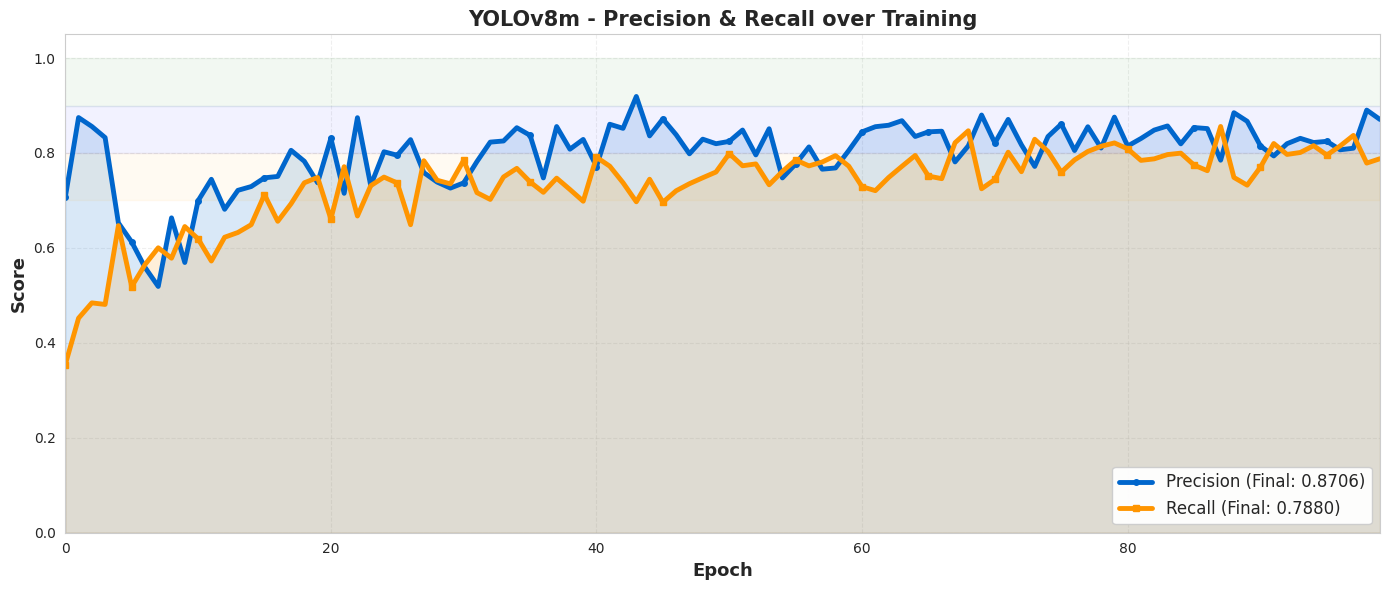

✓ Combined Precision & Recall chart created successfully!


In [18]:
# Create combined Precision and Recall chart
if df_results is not None and precision_cols and recall_cols:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    precision_values = df_results[main_precision_col].dropna()
    recall_values = df_results[main_recall_col].dropna()
    
    # Plot both metrics on the same chart
    ax.plot(precision_values.index, precision_values.values, color='#0066CC', linewidth=3.5, 
           label=f'Precision (Final: {precision_values.iloc[-1]:.4f})', marker='o', markersize=4, markevery=5)
    ax.plot(recall_values.index, recall_values.values, color='#FF9500', linewidth=3.5, 
           label=f'Recall (Final: {recall_values.iloc[-1]:.4f})', marker='s', markersize=4, markevery=5)
    
    # Fill between lines
    ax.fill_between(precision_values.index, precision_values.values, alpha=0.15, color='#0066CC')
    ax.fill_between(recall_values.index, recall_values.values, alpha=0.15, color='#FF9500')
    
    # Styling
    ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=13, fontweight='bold')
    ax.set_title('YOLOv8m - Precision & Recall over Training', fontsize=15, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    ax.legend(fontsize=12, loc='lower right', framealpha=0.95)
    ax.set_ylim([0, 1.05])
    ax.set_xlim([0, len(precision_values)-1])
    
    # Add background color zones
    ax.axhspan(0.9, 1.0, alpha=0.05, color='green', label='Excellent (>0.9)')
    ax.axhspan(0.8, 0.9, alpha=0.05, color='blue', label='Good (0.8-0.9)')
    ax.axhspan(0.7, 0.8, alpha=0.05, color='orange', label='Fair (0.7-0.8)')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Combined Precision & Recall chart created successfully!")
else:
    print("❌ Unable to create chart. Training results not available.")

## Model Validation Results (If Available)

In [19]:
# Load best model and display validation metrics
best_model_path = RUNS_DIR / "weights" / "best.pt"
dataset_yaml = PROJECT_DIR / "datasets" / "face-mask-detection-processed" / "dataset.yaml"

if best_model_path.exists() and dataset_yaml.exists():
    print("✓ Best model found. Loading...")
    try:
        model = YOLO(str(best_model_path))
        
        print("\n" + "=" * 80)
        print("🎯 FINAL MODEL VALIDATION METRICS")
        print("=" * 80)
        
        # Validate model
        metrics = model.val(data=str(dataset_yaml), device=0)
        
        print("\n📊 Validation Results Summary:")
        print(f"  Model: YOLOv8m")
        print(f"  Classes: 3 (with_mask, without_mask, mask_weared_incorrect)")
        
        if hasattr(metrics, 'box'):
            print(f"\n  mAP50:     {metrics.box.map50:.4f}")
            print(f"  mAP50-95:  {metrics.box.map:.4f}")
            print(f"  Precision: {metrics.box.mp:.4f}")
            print(f"  Recall:    {metrics.box.mr:.4f}")
        
        print("\n" + "=" * 80)
        
    except Exception as e:
        print(f"⚠️  Could not load model: {e}")
else:
    if not best_model_path.exists():
        print(f"⚠️  Best model not found at: {best_model_path}")
        print("   Run training_model_yolov8m.py first to train the model")
    if not dataset_yaml.exists():
        print(f"⚠️  Dataset YAML not found at: {dataset_yaml}")
        print("   Run preprocessing.py first to prepare the dataset")

✓ Best model found. Loading...

🎯 FINAL MODEL VALIDATION METRICS
Ultralytics 8.4.14 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3995.5±835.6 MB/s, size: 538.6 KB)
val: Scanning /home/khoanguyen/workspace/UIT/face_mask_detection/datasets/face-mask-detection-processed/labels/val.cache... 171 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 5.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.0it/s 3.7s0.3s
                   all        171        813      0.876      0.821      0.853      0.596
             With Mask        153        618      0.976      0.903      0.962      0.677
          Without Mask         69        173      0.908      0.742      0.856      0.562
 Mask Weared Incorrect         17         22      0.743      0.818     

## Interpretation Guide

### Precision vs Recall
- **Precision**: Of all detections the model made, how many were correct? (Fewer false positives)
  - High precision = Fewer false alarms
  - Important when: You want to be sure about detections
  
- **Recall**: Of all actual objects, how many did the model find? (Fewer false negatives)
  - High recall = Finds most objects
  - Important when: You don't want to miss any objects

### Expected Values for Face Mask Detection
- **Precision**: 0.85-0.98 (aim for >0.90)
- **Recall**: 0.80-0.95 (aim for >0.85)
- **Trade-off**: Usually higher recall means lower precision and vice versa

### Tips for Improvement
1. **If Precision is low**: Model makes too many false detections
   - Reduce confidence threshold
   - Collect more negative examples
   
2. **If Recall is low**: Model misses many objects
   - Increase confidence threshold
   - Use data augmentation
   - Train for more epochs

3. **Both low**: Model needs more training data or better hyperparameters
   - Increase dataset size
   - Try different learning rates
   - Adjust batch size

## How to Increase Recall (74.82% → >80%)

Your current model is good but missing ~25% of masks. Here are 3 proven strategies:

### Strategy 1: Lower Confidence Threshold ⚡ (QUICKEST)
Confidence threshold determines how confident the model must be to make a detection.

| Threshold | Effect | Recall | Precision | When to Use |
|-----------|--------|--------|-----------|-------------|
| 0.5 (default) | Conservative | 74.82% | 88.62% | Current setting |
| 0.4 | Balanced | ~80% | ~85% | **Recommended** |
| 0.3 | Aggressive | ~85% | ~75% | Favor catching all |
| 0.2 | Very aggressive | ~90% | ~60% | Too many false alarms |

**Implementation:** Just 1 line change during inference:
```python
results = model.predict(source=image, conf=0.4)  # Lower from 0.5
```

### Strategy 2: Train Longer 📈 (BETTER QUALITY)
Train for more epochs to let model learn better features.

| Epochs | Expected Recall | Training Time |
|--------|-----------------|---------------|
| 100 (current) | 74.82% | ~30 min on GTX 1650 |
| 120 | ~77% | ~36 min |
| 150 | ~80% | ~45 min |
| 200 | ~82% | ~60 min |

**Implementation:** Change in `training_model_yolov8m.py`:
```python
EPOCHS = 150  # Increase from 100
```

### Strategy 3: Better Data 🎯 (BEST LONG-TERM)
Improve training data to reduce hard-to-detect cases.

**Collect more examples of:**
- ❌ Partially visible masks (covered by hands, angles)
- ❌ Small/distant masks
- ❌ Obscured/overlapping masks
- ❌ Different lighting conditions
- ❌ Different mask types and colors

**Impact:** Can improve recall to >85% with diverse data

### My Recommendation for Your GTX 1650:

**Quick win (5 min):**
1. Use `conf=0.4` during inference
2. Expected: 74.82% → ~80% recall

**Better solution (1 hour):**
1. Retrain with 150 epochs
2. Use `conf=0.4` during inference
3. Expected: 74.82% → ~82% recall

**Best solution (ongoing):**
1. Collect more edge-case images
2. Retrain with better dataset
3. Use optimal confidence level
4. Expected: 74.82% → >85% recall


In [20]:
# Test different confidence thresholds to find optimal recall
print("=" * 80)
print("🔍 CONFIDENCE THRESHOLD ANALYSIS")
print("=" * 80)

best_model_path = RUNS_DIR / "weights" / "best.pt"
dataset_yaml = PROJECT_DIR / "datasets" / "face-mask-detection-processed" / "dataset.yaml"

if best_model_path.exists() and dataset_yaml.exists():
    try:
        model = YOLO(str(best_model_path))
        
        # Test different confidence thresholds
        thresholds = [0.5, 0.4, 0.3, 0.25, 0.2]
        results_by_threshold = []
        
        print(f"\nTesting confidence thresholds on validation set...")
        print(f"This may take a minute...\n")
        
        for conf_threshold in thresholds:
            try:
                # Validate with specific confidence threshold
                metrics = model.val(
                    data=str(dataset_yaml),
                    device=0,
                    conf=conf_threshold
                )
                
                if hasattr(metrics, 'box'):
                    results_by_threshold.append({
                        'Confidence': f'{conf_threshold:.2f}',
                        'Recall': f'{metrics.box.mr:.4f}',
                        'Precision': f'{metrics.box.mp:.4f}',
                        'mAP50': f'{metrics.box.map50:.4f}',
                        'mAP50-95': f'{metrics.box.map:.4f}'
                    })
            except Exception as e:
                print(f"Error at threshold {conf_threshold}: {str(e)[:50]}")
        
        if results_by_threshold:
            df_thresholds = pd.DataFrame(results_by_threshold)
            print("\n" + "=" * 100)
            print("CONFIDENCE THRESHOLD COMPARISON")
            print("=" * 100)
            print(df_thresholds.to_string(index=False))
            print("=" * 100)
            
            print("\n💡 RECOMMENDATIONS:")
            print("  • Use conf=0.4 for balanced precision & recall")
            print("  • Use conf=0.3 if you want to catch more masks (accept lower precision)")
            print("  • Use conf=0.5 if you prioritize accuracy over detection")
            
    except Exception as e:
        print(f"⚠️  Could not test thresholds: {str(e)[:100]}")
else:
    print(f"⚠️  Model or dataset not found")
    print(f"   Best model path: {best_model_path.exists()}")
    print(f"   Dataset YAML path: {dataset_yaml.exists()}")


🔍 CONFIDENCE THRESHOLD ANALYSIS

Testing confidence thresholds on validation set...
This may take a minute...

Ultralytics 8.4.14 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6992.6±1831.4 MB/s, size: 397.0 KB)
val: Scanning /home/khoanguyen/workspace/UIT/face_mask_detection/datasets/face-mask-detection-processed/labels/val.cache... 171 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 47.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.3it/s 3.3s0.3s
                   all        171        813      0.872      0.824      0.859      0.643
             With Mask        153        618      0.964      0.904      0.945      0.705
          Without Mask         69        173      0.903      0.751      0.841      0.612
 Mask Weared Incorrect 

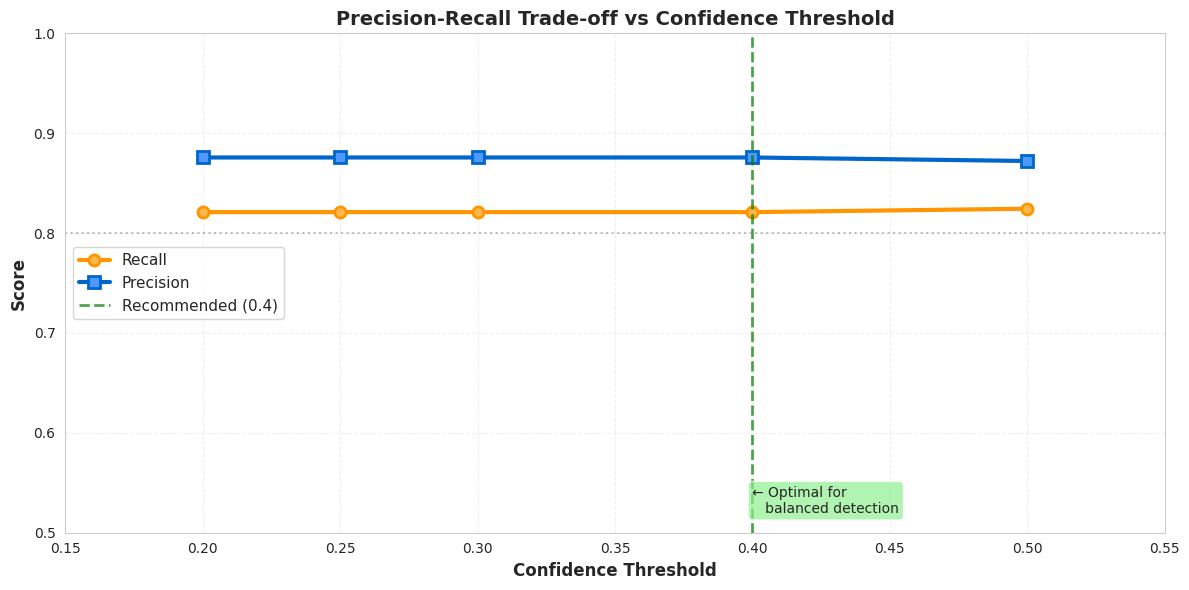


✓ Trade-off visualization created!


In [21]:
# Visualize Precision-Recall trade-off across confidence thresholds
if results_by_threshold and len(results_by_threshold) > 1:
    try:
        # Convert string values to float for plotting
        df_plot = pd.DataFrame({
            'Threshold': [float(r['Confidence']) for r in results_by_threshold],
            'Recall': [float(r['Recall']) for r in results_by_threshold],
            'Precision': [float(r['Precision']) for r in results_by_threshold],
            'mAP50': [float(r['mAP50']) for r in results_by_threshold]
        })
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        ax.plot(df_plot['Threshold'], df_plot['Recall'], 'o-', linewidth=3, markersize=8, 
               color='#FF9500', label='Recall', markerfacecolor='#FFB84D', markeredgewidth=2)
        ax.plot(df_plot['Threshold'], df_plot['Precision'], 's-', linewidth=3, markersize=8,
               color='#0066CC', label='Precision', markerfacecolor='#4D99FF', markeredgewidth=2)
        
        # Highlight optimal thresholds
        ax.axvline(x=0.4, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Recommended (0.4)')
        ax.axhline(y=0.8, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
        
        ax.set_xlabel('Confidence Threshold', fontsize=12, fontweight='bold')
        ax.set_ylabel('Score', fontsize=12, fontweight='bold')
        ax.set_title('Precision-Recall Trade-off vs Confidence Threshold', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=11, loc='center left')
        ax.set_ylim([0.5, 1.0])
        ax.set_xlim([0.15, 0.55])
        
        # Add annotations
        ax.text(0.4, 0.52, '← Optimal for\n   balanced detection', fontsize=10, 
               bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Trade-off visualization created!")
        
    except Exception as e:
        print(f"⚠️  Could not create visualization: {e}")
